# Train model

In [1]:
import os
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import hayai_util

portfolio_id = 'mix_train'
label_column = 'target'

context = hayai_util.create_context(portfolio_id)

## Step 1: build the dataset

In [2]:
filename = os.path.join(context['portfolio_dir'], "features.parquet")
df = pd.read_parquet(filename)
# unisci le righe di tutti i dataframe in uno solo
df = df.dropna()
df.shape

(334640, 41)

## EDA

In [3]:
df.describe()

,open,high,low,close,volume,trade_count,vwap,day_of_week,time_since_high,log_return,...,GC,NZDUSD,USDCAD,USDCHF,USDJPY,^DJI,^GSPC,^IXIC,^RUT,^VIX1D
count,334640.000000,334640.000000,334640.000000,334640.000000,3.346400e+05,3.346400e+05,334640.000000,334640.000000,334640.000000,334640.000000,...,334640.000000,334640.000000,334640.000000,334640.000000,334640.000000,334640.000000,334640.000000,334640.000000,334640.000000,334640.000000
mean,95.379369,96.632678,94.128299,95.390452,2.774899e+06,2.486248e+04,95.394482,2.022308,409.780848,0.002802,...,2791.230037,0.596885,1.374745,0.859481,149.251730,40815.273178,5540.535245,17841.993675,2130.082806,14.134604
std,129.279614,130.881790,127.625931,129.265273,7.776253e+06,3.615547e+04,129.270323,1.402056,345.855115,0.067737,...,839.393462,0.018270,0.029168,0.042599,5.657730,4661.409794,842.254189,3309.671987,246.089650,6.755319
min,0.043100,0.058100,0.039050,0.049900,2.000000e+02,2.000000e+00,0.045408,0.000000,0.000000,-2.294230,...,1816.599976,0.551849,1.311250,0.763200,133.464996,32417.589844,4055.989990,11799.160156,1636.939941,7.010000
25%,25.040000,25.270000,24.820000,25.050000,3.721212e+05,8.148750e+03,25.047536,1.000000,65.000000,-0.023045,...,2029.900024,0.584300,1.355910,0.815940,145.436996,37683.011719,4780.939941,15011.349609,1958.939941,10.320000
50%,53.520000,54.277500,52.775000,53.530000,1.002712e+06,1.551400e+04,53.546397,2.000000,378.000000,0.002524,...,2600.000000,0.597200,1.370420,0.874640,149.160004,40896.531250,5595.759766,17732.599609,2095.189941,12.470000
75%,111.210000,112.670000,109.800000,111.240000,2.439696e+06,2.949000e+04,111.220071,3.000000,680.000000,0.028401,...,3331.600098,0.610859,1.388980,0.895610,154.085999,44421.910156,6092.180176,20026.769531,2283.129883,15.950000
max,1969.800000,1999.999900,1948.480000,1978.320000,9.406834e+08,3.119769e+06,1972.926285,4.000000,1246.000000,4.454347,...,5318.399902,0.639190,1.471700,0.920970,161.606995,50188.140625,6978.600098,23958.470703,2718.770020,81.889999


In [4]:
df = df.drop(columns=['date', 'symbol'])
df.info()

<class 'pandas.DataFrame'>
Index: 334640 entries, 487 to 558703
Data columns (total 39 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   open             334640 non-null  float64
 1   high             334640 non-null  float64
 2   low              334640 non-null  float64
 3   close            334640 non-null  float64
 4   volume           334640 non-null  float64
 5   trade_count      334640 non-null  float64
 6   vwap             334640 non-null  float64
 7   day_of_week      334640 non-null  int32  
 8   time_since_high  334640 non-null  int64  
 9   log_return       334640 non-null  float64
 10  mom_5            334640 non-null  float64
 11  mom_10           334640 non-null  float64
 12  mom_20           334640 non-null  float64
 13  vol_10           334640 non-null  float64
 14  vol_20           334640 non-null  float64
 15  vol_ratio        334640 non-null  float64
 16  zscore_20        334640 non-null  float64
 17  trend

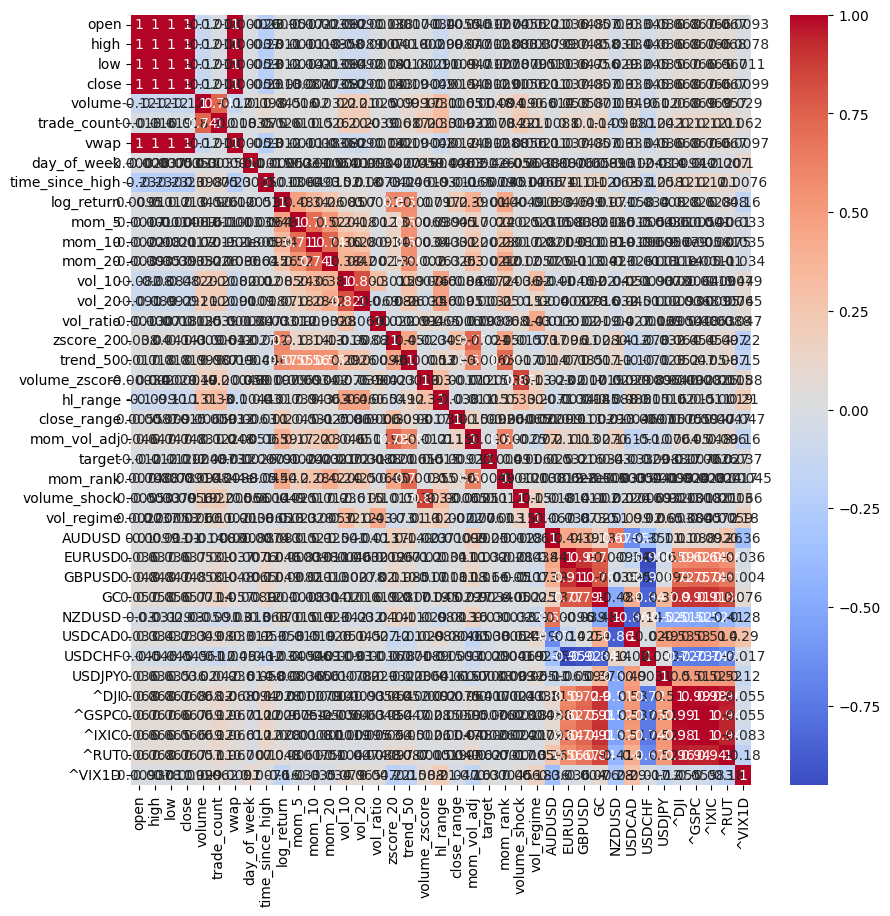

In [ ]:
# display the correlation map using seaborn
plt.figure(figsize=(20, 20))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

## Normalize

In [6]:
maxs = df.max()
mins = df.min()
df = (df - mins) / (maxs - mins)
label_min = mins[label_column]
label_max = maxs[label_column]
hayai_util.save_normalization_params(label_min, label_max)

True

## Model building

In [7]:
labels = df[label_column].values
df = df.drop(columns=[label_column])
data = df.values


In [8]:
from keras.models import Sequential
from keras.layers import Input, Dense,Conv1D,Conv2D,Flatten,MaxPool2D,BatchNormalization,MaxPooling1D
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
print("Labels Shape: %s" % (labels.shape,))
print("Data Shape: %s" % (data.shape,))
X, X_test, Y, Y_test = train_test_split(data, labels, test_size=0.2, random_state=1,shuffle=True)
print("Train Data Shape: %s" % (X.shape,))
print("Train Labels Shape: %s" % (Y.shape,))
print("Test Data Shape: %s" % (X_test.shape,))
print("Test Labels Shape: %s" % (Y_test.shape,))

Labels Shape: (334640,)
Data Shape: (334640, 38)
Train Data Shape: (267712, 38)
Train Labels Shape: (267712,)
Test Data Shape: (66928, 38)
Test Labels Shape: (66928,)


In [9]:
n_row = data.shape[1]
channels = 1 # non ci sono colori, il channel è 1 (usato solo in Conv2D)
batch_size = 64

model = Sequential()
model.add(Input(shape=(n_row,), name='input_layer'))
model.add(Dense(32, activation='relu',name='layerDense1'))
model.add(Dense(16, activation='relu',name='layerDense2'))
model.add(Dense(8, activation='relu',name='layerDense3'))
model.add(Dense(1,activation='sigmoid',name='output_layer'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layerDense1 (Dense)             │ (None, 32)             │         1,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense2 (Dense)             │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense3 (Dense)             │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,921 (7.50 KB)

 Trainable params: 1,921 (7.50 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# questa è la funzione di costo
optimizer = Adam(learning_rate=context['learning_rate'])
model.compile(loss='mean_squared_error', optimizer=optimizer)
#model.compile(loss='mean_squared_error', optimizer='SGD')

# questo è il training
model.fit(
    X,
    Y,
    epochs=context['epochs'],
    shuffle=True,
    verbose=2,
    batch_size=context['batch_size'],
    validation_split=context['validation_split']
)
# il modello è pronto, applichiamo il modello al dataset di test

results = model.evaluate(X_test, Y_test, verbose=2,)
print("Test loss: %f" % results)
filename = os.path.join(context['portfolio_dir'], 'model_summary.txt')
with open(filename, 'w',encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
model.save(os.path.join(context['portfolio_dir'], 'model.keras'))
print("Model saved to: %s" % os.path.join(context['portfolio_dir'], 'model.keras'))

Epoch 1/20
3347/3347 - 4s - 1ms/step - loss: 2.0258e-04 - val_loss: 1.1768e-04
Epoch 2/20
3347/3347 - 3s - 1ms/step - loss: 1.2093e-04 - val_loss: 1.1281e-04
Epoch 3/20
3347/3347 - 4s - 1ms/step - loss: 1.1790e-04 - val_loss: 1.1661e-04
Epoch 4/20
3347/3347 - 4s - 1ms/step - loss: 1.1618e-04 - val_loss: 1.1162e-04
Epoch 5/20
3347/3347 - 4s - 1ms/step - loss: 1.1517e-04 - val_loss: 1.1240e-04
Epoch 6/20
3347/3347 - 5s - 2ms/step - loss: 1.1445e-04 - val_loss: 1.0957e-04
Epoch 7/20
3347/3347 - 5s - 1ms/step - loss: 1.1392e-04 - val_loss: 1.1102e-04
Epoch 8/20
3347/3347 - 3s - 1ms/step - loss: 1.1319e-04 - val_loss: 1.0869e-04
Epoch 9/20
3347/3347 - 4s - 1ms/step - loss: 1.1281e-04 - val_loss: 1.0820e-04
Epoch 10/20
3347/3347 - 4s - 1ms/step - loss: 1.1236e-04 - val_loss: 1.0901e-04
Epoch 11/20
3347/3347 - 4s - 1ms/step - loss: 1.1180e-04 - val_loss: 1.0910e-04
Epoch 12/20
3347/3347 - 4s - 1ms/step - loss: 1.1145e-04 - val_loss: 1.0701e-04
Epoch 13/20
3347/3347 - 4s - 1ms/step - loss: 1.1

Model saved to: data\mix_train\model.keras


In [11]:
tp = 0
tn = 0
fp = 0
fn = 0
print(label_min, label_max, label_max - label_min)
#denormalize labels
labels = Y_test * (label_max - label_min) + label_min
predictions = model.predict(X_test, verbose=0)
errors = []
for i in range(len(X_test)):
    p = predictions[i][0]
    label = labels[i]
    p = p * (label_max - label_min) + label_min # denormalize prediction
    if i < 30:
        print(f"Label: {label:.4f}, Prediction: {p:.4f}")
    errors.append((label - p))
    if label > 0 and p > 0:
        tp += 1
    elif label <= 0 and p <= 0:
        tn += 1
    elif label <= 0 and p > 0:
        fp += 1
    elif label > 0 and p <= 0:
        fn += 1
eqm = math.sqrt(sum([e**2 for e in errors])/len(errors))
print(f"Mean Squared Error: {eqm:.4f}")
print("True Positives: %d, True Negatives: %d, False Positives: %d, False Negatives: %d" % (tp, tn, fp, fn))
print("positive labels: %d, negative labels: %d" % (sum(labels > 0), sum(labels <= 0)))
print("Sum true",tp+tn, "Sum false",fp+fn)
print("Precision: %.4f" % (tp / (tp + fp) if (tp + fp) > 0 else 0))
print("Recall: %.4f" % (tp / (tp + fn) if (tp + fn) > 0 else 0))
print("Accuracy: %.4f" % ((tp + tn) / len(X_test) if len(X_test) > 0 else 0))

-96.56674064883275 53.299020865400934 149.86576151423367
Label: 0.8278, Prediction: 1.2833
Label: 0.3258, Prediction: 0.0759
Label: -0.3644, Prediction: 0.6447
Label: 0.4598, Prediction: 0.1292
Label: 0.2484, Prediction: 0.5095
Label: 0.2747, Prediction: -0.5423
Label: -0.0821, Prediction: -0.0815
Label: 0.2759, Prediction: 0.2233
Label: -1.6699, Prediction: -0.0796
Label: 2.5558, Prediction: -0.0784
Label: 1.0811, Prediction: -0.0428
Label: 0.8169, Prediction: -0.0286
Label: 0.4195, Prediction: 0.4878
Label: -0.0251, Prediction: 0.2984
Label: 0.8408, Prediction: 0.4713
Label: 9.6811, Prediction: 0.6415
Label: -0.1998, Prediction: 0.1087
Label: -0.5253, Prediction: 0.1544
Label: -0.0061, Prediction: 0.3542
Label: 0.9217, Prediction: 0.7321
Label: 0.1313, Prediction: 0.0011
Label: 0.4881, Prediction: 0.5798
Label: 0.9723, Prediction: 0.7616
Label: -0.5916, Prediction: 0.1006
Label: -0.1522, Prediction: 0.6043
Label: -0.1408, Prediction: 0.3068
Label: -1.0207, Prediction: -0.2477
Label: 